In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


share_link = "https://drive.google.com/file/d/1biE2veK-D9WcDJPpsJpt0P4hGTbxKoZm/view?usp=drive_link"
file_id = share_link.split('/d/')[1].split('/view')[0]
csv_url = f"https://docs.google.com/uc?export=download&id={"1biE2veK-D9WcDJPpsJpt0P4hGTbxKoZm"}"
df = pd.read_csv(csv_url)


In [ ]:
df['outbreak_burden'] = (df['total-infected-ever'] > 0.20 * df['number-people']).astype(int)
df['outbreak_active'] = (df['peak-sick'] > 8).astype(int)

In [ ]:
C_VAC  = '#2E86AB'   # blue — vaccination
C_CULL = '#E84855'   # red — culling
C_POP  = '#F6AE2D'   # yellow — population
C_BG   = '#F8F9FA'   # light background
C_DARK = '#1A1A2E'

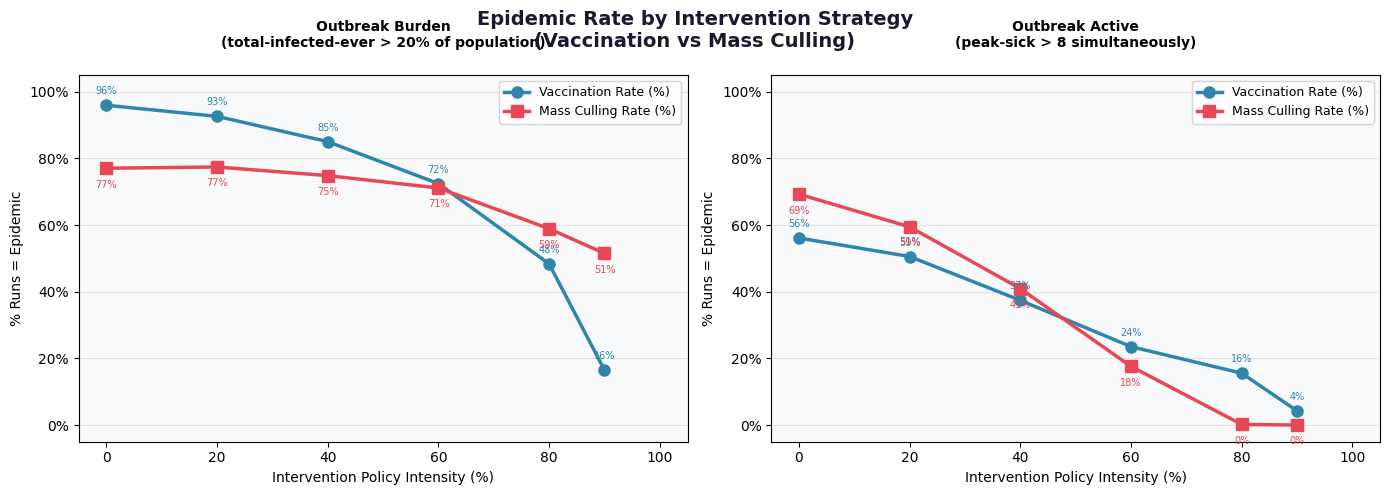

Figure 1 saved.


In [ ]:
fig1, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig1.suptitle('Epidemic Rate by Intervention Strategy\n(Vaccination vs Mass Culling)',
              fontsize=14, fontweight='bold', color=C_DARK)

for ax, label, title in zip(
    axes,
    ['outbreak_burden', 'outbreak_active'],
    ['Outbreak Burden\n(total-infected-ever > 20% of population)',
     'Outbreak Active\n(peak-sick > 8 simultaneously)']
):
    vax  = df.groupby('vaccination-rate')[label].mean() * 100
    cull = df.groupby('culling-rate')[label].mean() * 100

    # NO MORE twiny()! Both plot directly to the same axis (ax)
    ax.plot(vax.index, vax.values, 'o-', color=C_VAC, linewidth=2.5,
            markersize=8, label='Vaccination Rate (%)', zorder=3)
    ax.plot(cull.index, cull.values, 's-', color=C_CULL, linewidth=2.5,
            markersize=8, label='Mass Culling Rate (%)', zorder=3)

    ax.set_title(title, fontsize=10, fontweight='bold', pad=20)
    ax.set_xlabel('Intervention Policy Intensity (%)', fontsize=10) # Unified label
    ax.set_ylabel('% Runs = Epidemic', fontsize=10)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    ax.set_facecolor(C_BG)

    # Slight padding so annotations don't get cut off
    ax.set_ylim(-5, 105)
    ax.set_xlim(-5, 105)
    ax.grid(axis='y', alpha=0.3)

    # Simplified legend (since both lines are on the same axis now)
    ax.legend(fontsize=9, loc='upper right')

    # Annotate vaccination points
    for x, y in zip(vax.index, vax.values):
        ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color=C_VAC)

    # Annotate culling points
    for x, y in zip(cull.index, cull.values):
        ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                    xytext=(0, -14), ha='center', fontsize=7, color=C_CULL)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Adds a little space for the main title
plt.savefig('fig1_epidemic_rate_lines_UPDATED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

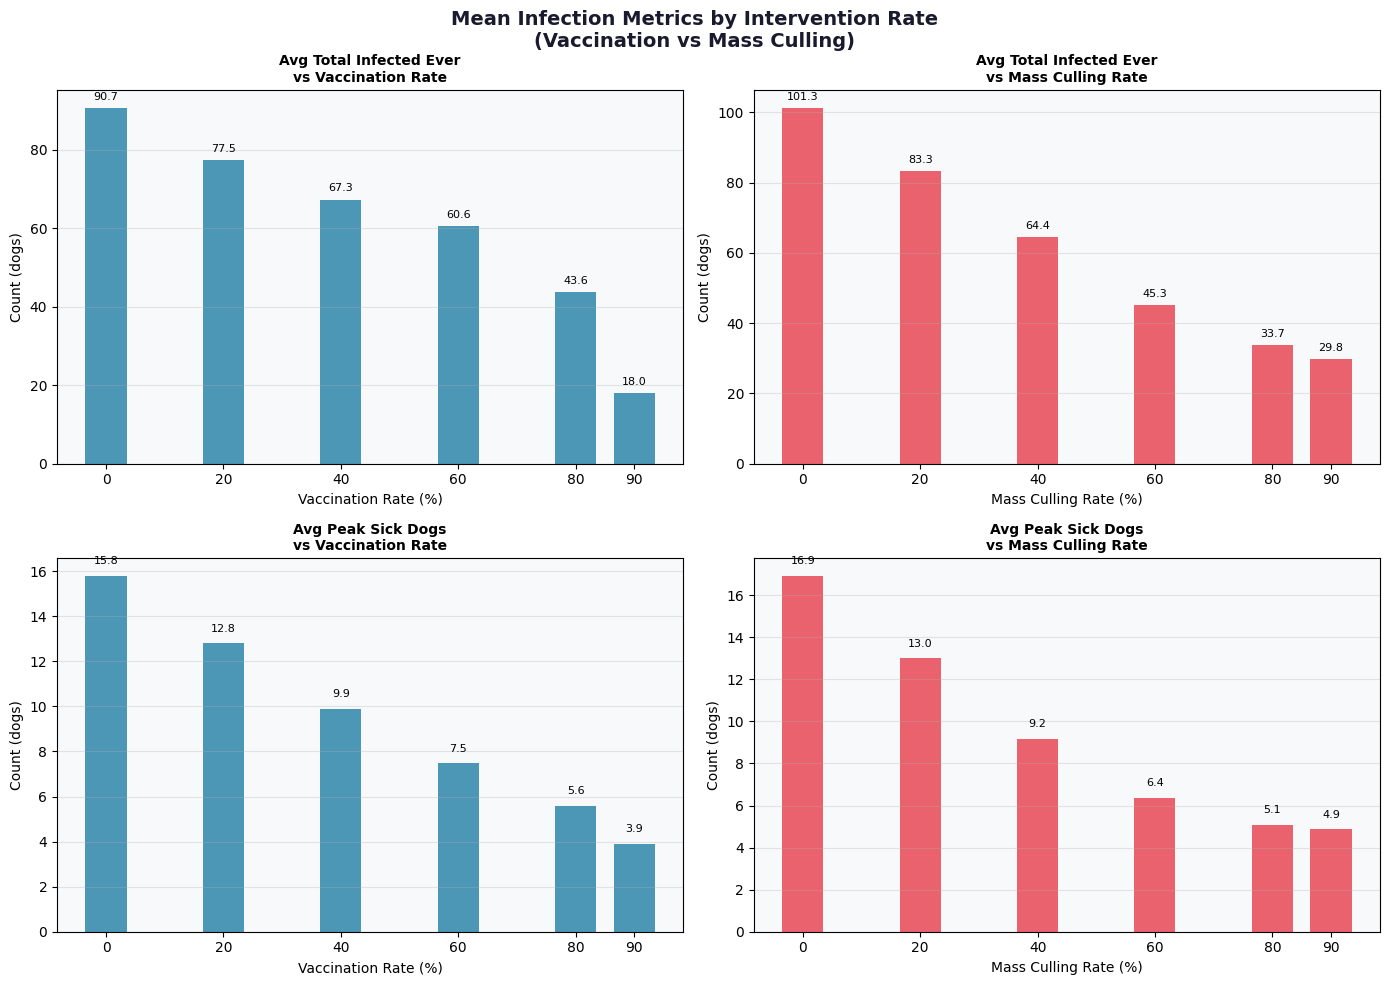

Figure 2 saved.


In [ ]:
# FIGURE 2 — Mean Total Infected & Peak Sick (Bar Charts)

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
fig2.suptitle('Mean Infection Metrics by Intervention Rate\n(Vaccination vs Mass Culling)',
              fontsize=14, fontweight='bold', color=C_DARK)

# UPDATED: Both culling datasets now use width=7 and xticklabels=None
# to perfectly match the new 0-100% integer scale.
datasets = [
    (axes2[0,0], 'vaccination-rate', 'total-infected-ever', C_VAC,
     'Avg Total Infected Ever\nvs Vaccination Rate',
     'Vaccination Rate (%)', 7, None),

    (axes2[0,1], 'culling-rate', 'total-infected-ever', C_CULL,
     'Avg Total Infected Ever\nvs Mass Culling Rate',
     'Mass Culling Rate (%)', 7, None),

    (axes2[1,0], 'vaccination-rate', 'peak-sick', C_VAC,
     'Avg Peak Sick Dogs\nvs Vaccination Rate',
     'Vaccination Rate (%)', 7, None),

    (axes2[1,1], 'culling-rate', 'peak-sick', C_CULL,
     'Avg Peak Sick Dogs\nvs Mass Culling Rate',
     'Mass Culling Rate (%)', 7, None),
]

for ax, groupby, metric, color, title, xlabel, width, xticklabels in datasets:
    data = df.groupby(groupby)[metric].mean()
    bars = ax.bar(data.index, data.values, color=color,
                  alpha=0.85, width=width)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Count (dogs)', fontsize=10)
    ax.set_facecolor(C_BG)
    ax.grid(axis='y', alpha=0.3)

    # Force the x-ticks to display exactly your tested values (0, 20, 40, 60, 80, 90)
    ax.set_xticks(data.index)

    # Dynamic label padding offset based on the maximum value in the chart
    # to avoid text overlapping the top borders of the bars
    y_offset = max(data.values) * 0.015 + 0.2

    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + y_offset,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(top=0.90) # Leaves room for the main overarching title
plt.savefig('fig2_mean_metrics_bars_UPDATED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

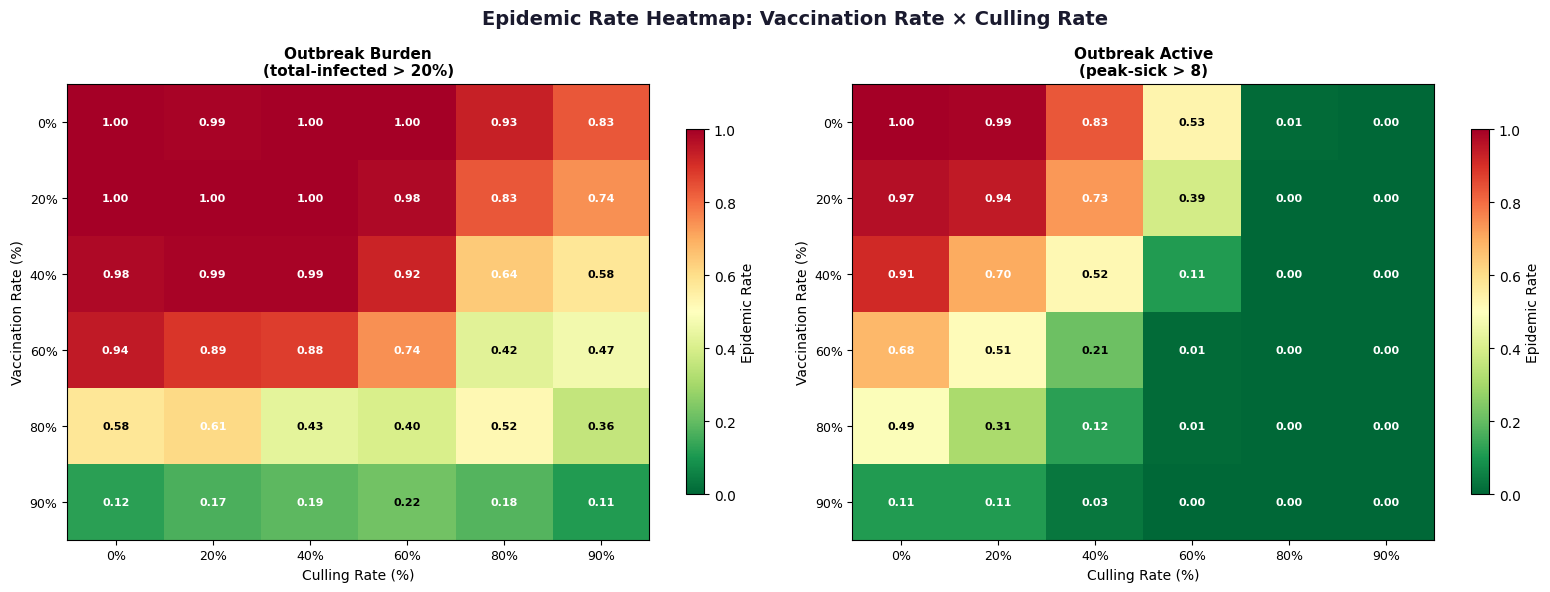

Figure 3 saved.


In [ ]:
# FIGURE 3 — Heatmaps: Vaccination x Culling

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
fig3.suptitle('Epidemic Rate Heatmap: Vaccination Rate × Culling Rate',
              fontsize=14, fontweight='bold', color=C_DARK)

for ax, label, title in zip(
    axes3,
    ['outbreak_burden', 'outbreak_active'],
    ['Outbreak Burden\n(total-infected > 20%)',
     'Outbreak Active\n(peak-sick > 8)']
):
    pivot = df.groupby(['vaccination-rate', 'culling-rate'])[label].mean().unstack()
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{c}%' for c in pivot.columns], fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{r}%' for r in pivot.index], fontsize=9)
    ax.set_xlabel('Culling Rate (%)',     fontsize=10)
    ax.set_ylabel('Vaccination Rate (%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Epidemic Rate')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            text_color = 'white' if val > 0.6 or val < 0.2 else 'black'
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color=text_color)

plt.tight_layout()
plt.savefig('fig3_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")



AT ZERO VACCINATION — Effect of culling rate
              Total Infected  Peak Sick  Final Population  Infection Rate
culling-rate                                                             
0                     155.71      32.66              6.44            0.95
20                    128.22      24.60             11.52            0.91
40                    104.37      16.96             13.38            0.87
60                     73.09       9.66             21.38            0.76
80                     44.83       5.69             28.30            0.62
90                     37.99       5.19             19.22            0.67

→ As culling increases, total infected drops slightly but
  final population collapses — and infection RATE increases.
  Culling 'controls' rabies by eliminating the population.

TOTAL INFECTED EVER — vaccination × culling
culling-rate         0      20     40    60    80    90
vaccination-rate                                       
0                 155.7  12

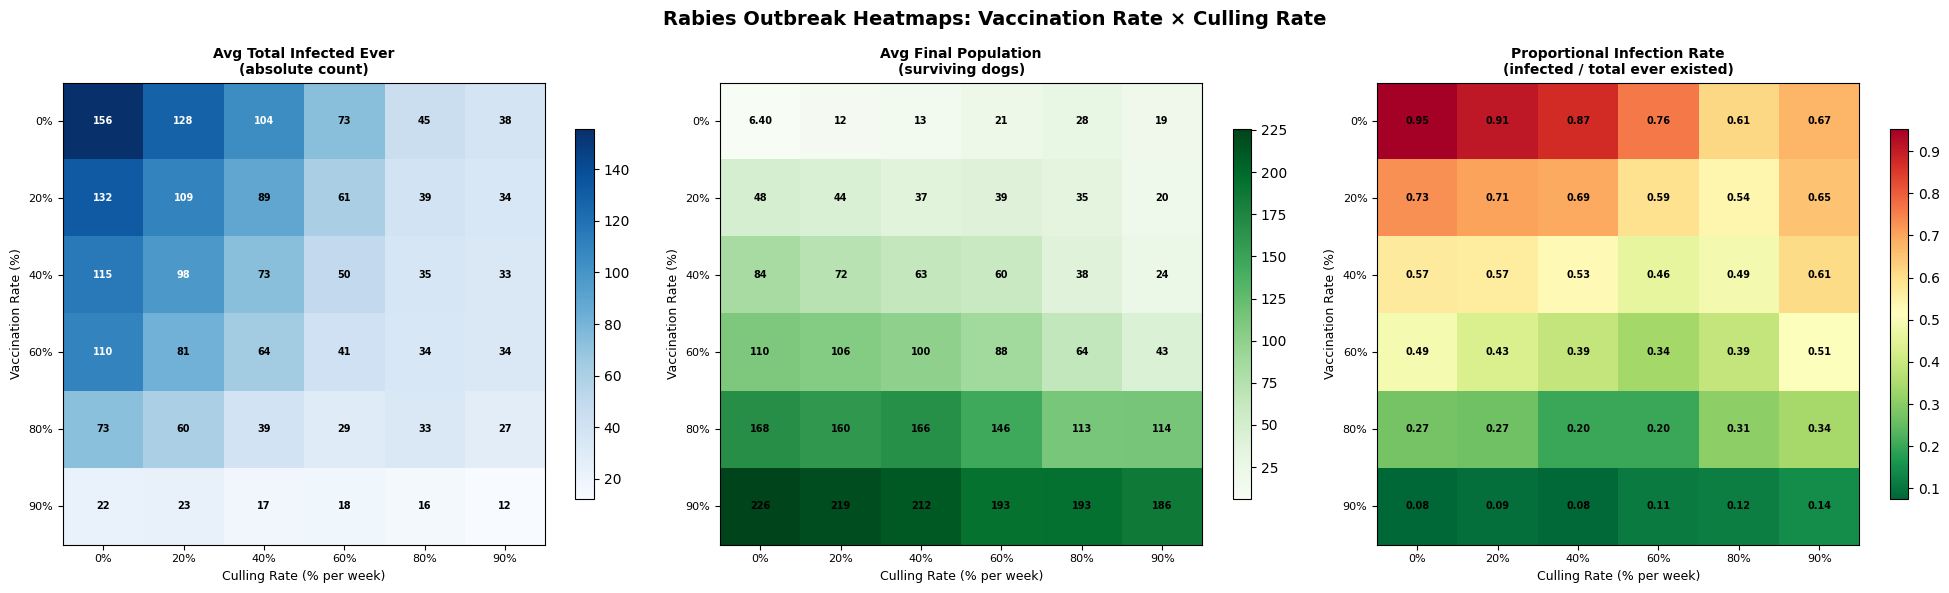

Proportional heatmap saved!


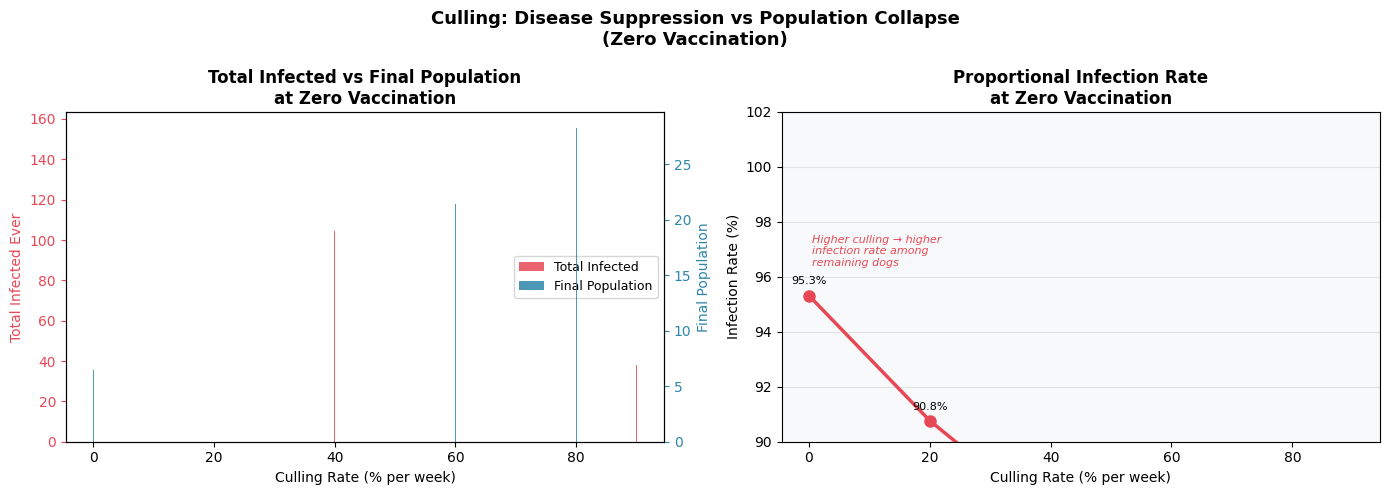

Culling collapse figure saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ── Labels ──
df['outbreak_burden'] = (df['total-infected-ever'] > 0.20 * df['number-people']).astype(int)
df['outbreak_active']  = (df['peak-sick'] > 8).astype(int)

# ── Proportional infection rate ──
# Approximate total dogs ever in simulation
# = final survivors + everyone who ever got infected
df['approx_total_dogs'] = df['count turtles'] + df['total-infected-ever']
df['infection_rate']    = df['total-infected-ever'] / df['approx_total_dogs']

# ════════════════════════════════════════════════════
# TABLE 1 — Zero vaccination: culling effect
# ════════════════════════════════════════════════════
print("=" * 65)
print("AT ZERO VACCINATION — Effect of culling rate")
print("=" * 65)
no_vax = df[df['vaccination-rate'] == 0]
table1 = no_vax.groupby('culling-rate')[
    ['total-infected-ever', 'peak-sick', 'count turtles', 'infection_rate']
].mean().round(2)
table1.columns = ['Total Infected', 'Peak Sick', 'Final Population', 'Infection Rate']
print(table1.to_string())
print()
print("→ As culling increases, total infected drops slightly but")
print("  final population collapses — and infection RATE increases.")
print("  Culling 'controls' rabies by eliminating the population.")
print()

# ════════════════════════════════════════════════════
# TABLE 2 — All vaccination x culling combinations
# ════════════════════════════════════════════════════
print("=" * 65)
print("TOTAL INFECTED EVER — vaccination × culling")
print("=" * 65)
pivot_total = df.groupby(
    ['vaccination-rate', 'culling-rate']
)['total-infected-ever'].mean().unstack().round(1)
print(pivot_total.to_string())
print()

print("=" * 65)
print("PEAK SICK — vaccination × culling")
print("=" * 65)
pivot_peak = df.groupby(
    ['vaccination-rate', 'culling-rate']
)['peak-sick'].mean().unstack().round(1)
print(pivot_peak.to_string())
print()

print("=" * 65)
print("FINAL POPULATION — vaccination × culling")
print("=" * 65)
pivot_pop = df.groupby(
    ['vaccination-rate', 'culling-rate']
)['count turtles'].mean().unstack().round(1)
print(pivot_pop.to_string())
print()

print("=" * 65)
print("PROPORTIONAL INFECTION RATE — vaccination × culling")
print("(total-infected / approx total dogs ever)")
print("=" * 65)
pivot_rate = df.groupby(
    ['vaccination-rate', 'culling-rate']
)['infection_rate'].mean().unstack().round(3)
print(pivot_rate.to_string())
print()

# ════════════════════════════════════════════════════
# FIGURE — Proportional infection heatmap
# ════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')
fig.suptitle(
    'Rabies Outbreak Heatmaps: Vaccination Rate × Culling Rate',
    fontsize=14, fontweight='bold'
)

heatmap_data = [
    (pivot_total,  'Avg Total Infected Ever\n(absolute count)',           'Blues'),
    (pivot_pop,    'Avg Final Population\n(surviving dogs)',              'Greens'),
    (pivot_rate,   'Proportional Infection Rate\n(infected / total ever existed)', 'RdYlGn_r'),
]

for ax, (pivot, title, cmap) in zip(axes, heatmap_data):
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{c}%' for c in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{r}%' for r in pivot.index], fontsize=8)
    ax.set_xlabel('Culling Rate (% per week)', fontsize=9)
    ax.set_ylabel('Vaccination Rate (%)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.2f}' if val < 10 else f'{val:.0f}',
                    ha='center', va='center', fontsize=7,
                    fontweight='bold', color='white' if cmap == 'Blues'
                    and val > pivot.values.max() * 0.6 else 'black')

plt.tight_layout()
plt.savefig('fig_proportional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Proportional heatmap saved!")

# ════════════════════════════════════════════════════
# FIGURE — Population collapse vs disease suppression
# ════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig2.suptitle(
    'Culling: Disease Suppression vs Population Collapse\n(Zero Vaccination)',
    fontsize=13, fontweight='bold'
)

cull_vals = no_vax.groupby('culling-rate')[
    ['total-infected-ever', 'count turtles']
].mean()

# Left — total infected vs final population
ax = axes2[0]
x = cull_vals.index
width = 0.06
bars1 = ax.bar(x - width/2, cull_vals['total-infected-ever'],
               width=width, color='#E84855', alpha=0.85, label='Total Infected')
ax2_twin = ax.twinx()
bars2 = ax2_twin.bar(x + width/2, cull_vals['count turtles'],
                     width=width, color='#2E86AB', alpha=0.85, label='Final Population')
ax.set_xlabel('Culling Rate (% per week)', fontsize=10)
ax.set_ylabel('Total Infected Ever', fontsize=10, color='#E84855')
ax2_twin.set_ylabel('Final Population', fontsize=10, color='#2E86AB')
ax.set_title('Total Infected vs Final Population\nat Zero Vaccination', fontweight='bold')
ax.tick_params(axis='y', colors='#E84855')
ax2_twin.tick_params(axis='y', colors='#2E86AB')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)

# Right — proportional infection rate
ax3 = axes2[1]
rate_data = no_vax.groupby('culling-rate')['infection_rate'].mean() * 100
ax3.plot(rate_data.index, rate_data.values, 'o-',
         color='#E84855', linewidth=2.5, markersize=8)
for x_val, y_val in zip(rate_data.index, rate_data.values):
    ax3.annotate(f'{y_val:.1f}%', (x_val, y_val),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax3.set_xlabel('Culling Rate (% per week)', fontsize=10)
ax3.set_ylabel('Infection Rate (%)', fontsize=10)
ax3.set_title('Proportional Infection Rate\nat Zero Vaccination', fontweight='bold')
ax3.set_ylim(90, 102)
ax3.set_facecolor('#F8F9FA')
ax3.grid(axis='y', alpha=0.3)
ax3.annotate('Higher culling → higher\ninfection rate among\nremaining dogs',
             xy=(0.6, 96.4), fontsize=8, color='#E84855',
             style='italic')

plt.tight_layout()
plt.savefig('fig_culling_collapse.png', dpi=150, bbox_inches='tight')
plt.show()
print("Culling collapse figure saved!")

In [ ]:
!pip install scikit-learn